# 03 — Training Curves

Plot loss and accuracy curves from training logs.

In [7]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style("whitegrid")
LOG_DIR = Path("../outputs/logs")

# Parse training log file
log_path = LOG_DIR / "train.log"
epochs, train_loss, train_acc, val_loss, val_acc = [], [], [], [], []

# Regex pattern (robust against timestamps and formatting)
pattern = r"loss: ([0-9.]+).*acc: ([0-9.]+)"

if not log_path.exists():
    raise FileNotFoundError(f"Log file not found: {log_path}")

with open(log_path, "r") as f:
    for line in f:
        # Parse train metrics
        if "Train — loss" in line:
            match = re.search(pattern, line)
            if match:
                train_loss.append(float(match.group(1)))
                train_acc.append(float(match.group(2)))

        # Parse validation metrics
        elif "Val   — loss" in line:
            match = re.search(pattern, line)
            if match:
                val_loss.append(float(match.group(1)))
                val_acc.append(float(match.group(2)))
                epochs.append(len(epochs) + 1)


print(f"Parsed {len(epochs)} epochs")

Parsed 16 epochs


In [8]:
print(train_loss)

[1.1036, 1.1008, 1.073, 1.0304, 0.9921, 0.9261, 0.8622, 0.8175, 0.788, 0.7594, 0.7359, 0.7118, 0.6922, 0.6735, 0.661, 0.6444]


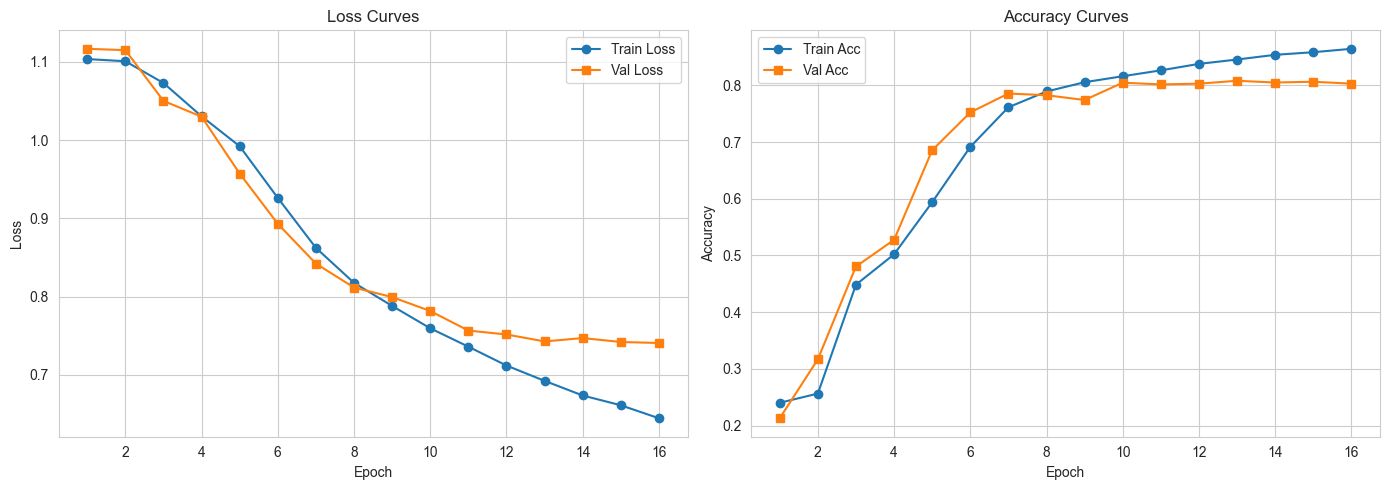

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_loss, label="Train Loss", marker="o")
axes[0].plot(epochs, val_loss, label="Val Loss", marker="s")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs, train_acc, label="Train Acc", marker="o")
axes[1].plot(epochs, val_acc, label="Val Acc", marker="s")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("../report/figures/03_training_curves.png", dpi=150)
plt.show()